# Module 11 — NMVOC Oxidation II: Aromatics and Oxygenated Organics
### B4 Chemistry in the Atmosphere · companion notebook

Covers: aromatic OH-abstraction vs OH-addition branching, Example 5 (initiation-pathway
comparison for an alkene), and a course-wrap-up NMVOC lifetime calculator that reuses
Module 7's OH steady-state machinery.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## Aromatic OH branching: abstraction vs addition

The notes quote H-abstraction yield <10%, OH-addition yield >90% for a toluene-like aromatic.

k(abstraction) = 3.60e-13 cm^3/s (6%)
k(addition)    = 5.64e-12 cm^3/s (94%)


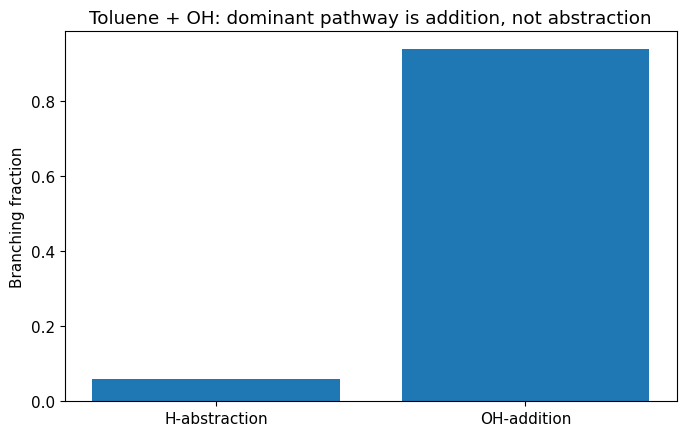

In [2]:
k_OH_total = 6e-12   # cm^3/s, toluene + OH overall rate constant (representative)
f_abstraction = 0.06   # ~6%, within the notes' <10% range
f_addition = 1 - f_abstraction

k_abstraction = k_OH_total * f_abstraction
k_addition = k_OH_total * f_addition

print(f"k(abstraction) = {k_abstraction:.2e} cm^3/s ({100*f_abstraction:.0f}%)")
print(f"k(addition)    = {k_addition:.2e} cm^3/s ({100*f_addition:.0f}%)")

plt.figure()
plt.bar(['H-abstraction', 'OH-addition'], [f_abstraction, f_addition])
plt.ylabel('Branching fraction')
plt.title('Toluene + OH: dominant pathway is addition, not abstraction')
plt.tight_layout()
plt.show()

## Example 5 — initiation pathway for an alkene (2-methyl-2-butene-like)

Compare pseudo-first-order initiation rates for OH, O3 and NO3 across day/night and
clean/polluted scenarios.

In [3]:
k_OH_alkene = 6e-11    # cm^3/s, typical trisubstituted alkene + OH
k_O3_alkene = 4e-16    # cm^3/s, typical alkene + O3 (ozonolysis)
k_NO3_alkene = 5e-12   # cm^3/s, typical alkene + NO3 (from the notes' 1e-12 to 1e-10 range)

scenarios = {
    'Day, clean':    dict(OH=1e6,  O3=4e11, NO3=1e5),
    'Day, polluted': dict(OH=5e6,  O3=8e11, NO3=1e5),
    'Night':         dict(OH=1e3,  O3=3e11, NO3=2.5e8),   # NO3 ~1 pptv = ~2.5e7 at surface; using notes' up-to-1pptv range
}

print(f"{'Scenario':16s}{'OH init (s^-1)':>16s}{'O3 init (s^-1)':>16s}{'NO3 init (s^-1)':>17s}{'Dominant':>12s}")
for name, c in scenarios.items():
    r_OH = k_OH_alkene*c['OH']
    r_O3 = k_O3_alkene*c['O3']
    r_NO3 = k_NO3_alkene*c['NO3']
    rates = {'OH': r_OH, 'O3': r_O3, 'NO3': r_NO3}
    dominant = max(rates, key=rates.get)
    print(f"{name:16s}{r_OH:16.2e}{r_O3:16.2e}{r_NO3:17.2e}{dominant:>12s}")

Scenario          OH init (s^-1)  O3 init (s^-1)  NO3 init (s^-1)    Dominant
Day, clean              6.00e-05        1.60e-04         5.00e-07          O3
Day, polluted           3.00e-04        3.20e-04         5.00e-07          O3
Night                   6.00e-08        1.20e-04         1.25e-03         NO3


This reproduces the qualitative picture from Modules 10-11: OH dominates alkene initiation
during the day, while at night -- when [OH] collapses -- NO3 (and, for less reactive alkenes, O3)
takes over, consistent with the notes' emphasis on NO3 as "the main night-time oxidant".

## Course wrap-up: NMVOC lifetime calculator

Combining Module 7's OH steady-state result with Table 2.2-style rate constants, and now also
O3/NO3 pathways from this module, to get an overall multi-oxidant lifetime for a chosen NMVOC.

In [4]:
def overall_lifetime(k_OH, k_O3=0, k_NO3=0, OH=1e6, O3=8e11, NO3_night_avg=2.5e7,
                      day_fraction=0.5):
    # Day: OH + O3 active; Night: O3 + NO3 active (OH ~ 0)
    rate_day = k_OH*OH + k_O3*O3
    rate_night = k_O3*O3 + k_NO3*NO3_night_avg
    rate_avg = day_fraction*rate_day + (1-day_fraction)*rate_night
    return 1/rate_avg

compounds = {
    'Ethane (alkane)':          dict(k_OH=2.7e-13, k_O3=0,     k_NO3=0),
    'Isoprene (alkene)':        dict(k_OH=1.0e-10, k_O3=1.3e-17, k_NO3=7.0e-13),
    'Toluene (aromatic)':       dict(k_OH=6.0e-12, k_O3=0,     k_NO3=7e-17),
}

print(f"{'Compound':22s}{'Lifetime':>15s}")
for name, k in compounds.items():
    tau_s = overall_lifetime(**k)
    if tau_s < 3600:
        print(f"{name:22s}{tau_s/60:14.1f}m")
    elif tau_s < 86400:
        print(f"{name:22s}{tau_s/3600:14.1f}h")
    else:
        print(f"{name:22s}{tau_s/86400:14.1f}d")

Compound                     Lifetime
Ethane (alkane)                 85.7d
Isoprene (alkene)                4.0h
Toluene (aromatic)               3.9d


## Exercises

1. **Branching sensitivity.** If the aromatic H-abstraction fraction were 15% instead of 6% (i.e.
   at the upper end of plausible uncertainty), how much does the abstraction-pathway product flux
   (e.g. benzaldehyde-type products from toluene) change in absolute terms?

2. **Full Example 5 writeup.** Using the initiation-rate comparison above, write out a complete
   step-by-step oxidation mechanism for 2-methyl-2-butene under "day, polluted" conditions,
   following the OH-addition -> RO2 -> (R4.2, dominant at high NO) -> RO -> carbonyl pathway from
   Module 10. What are the expected major carbonyl products?

3. **Whole-course capstone.** Pick any three trace gases mentioned across this course (e.g. one
   from each of Modules 1, 6 and 10/11) and, using the steady-state and rate-constant tools built
   across all eleven notebooks, produce a single summary table of their approximate tropospheric
   lifetimes and dominant loss pathways. Does the ranking match your chemical intuition from the
   lecture notes?